# 🎯 MathQuest — Placement Model
## Model untuk Menentukan Level Awal Siswa Berdasarkan Hasil Pre-Test

**Apa yang dilakukan notebook ini?**
Notebook ini membangun model AI yang memprediksi apakah seorang siswa termasuk level **pemula**, **menengah**, atau **mahir** — berdasarkan hasil pre-test yang mereka kerjakan saat pertama kali mendaftar.

**Alur notebook:**
1. Install & import library
2. Konfigurasi
3. Custom Components (Layer, Loss, Callback)
4. Buat dataset dummy
5. Preprocessing
6. Bangun & training model
7. Evaluasi
8. Simpan model
9. Test inference (simulasi dipanggil dari aplikasi web)

---
> ⚠️ **Catatan:** Notebook ini menggunakan **data dummy** selama dataset Junyi Academy belum tersedia.  
> Saat dataset asli sudah didownload dari Kaggle, cukup ganti satu baris di bagian **Step 4**.


## Step 1 — Install Library

In [17]:
# Install semua library yang dibutuhkan
# Jalankan cell ini sekali saja — kalau sudah pernah install, skip
# Tanda ! di awal artinya perintah ini dijalankan di terminal, bukan Python
!pip install tensorflow numpy pandas scikit-learn joblib matplotlib


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Step 2 — Import Library & Konfigurasi

In [18]:
# os: untuk membuat folder dan mengecek keberadaan file
import os

# numpy: library untuk operasi matematika pada array angka
# hampir semua data di sini akhirnya berbentuk numpy array
import numpy as np

# pandas: library untuk membaca dan memanipulasi data tabel (seperti Excel)
import pandas as pd

# matplotlib: library untuk membuat grafik dan visualisasi
import matplotlib.pyplot as plt

# joblib: untuk menyimpan dan memuat objek Python ke file (dipakai untuk scaler)
import joblib

# tensorflow: library utama untuk membangun dan melatih model Deep Learning
import tensorflow as tf

# keras: bagian dari TensorFlow yang menyediakan API tingkat tinggi
# (lebih mudah dipakai daripada TensorFlow mentah)
from tensorflow import keras

# train_test_split: untuk memisahkan data menjadi bagian training dan testing
from sklearn.model_selection import train_test_split

# MinMaxScaler: untuk menormalisasi angka ke skala 0 sampai 1
from sklearn.preprocessing import MinMaxScaler

# classification_report: menampilkan akurasi, precision, recall per kelas
# confusion_matrix: menampilkan tabel prediksi benar vs salah per kelas
from sklearn.metrics import classification_report, confusion_matrix

# Cek versi TensorFlow yang terinstall
print('TensorFlow versi:', tf.__version__)

TensorFlow versi: 2.21.0


## Step 3 — Konfigurasi

In [19]:
# ── Pemetaan kelas ke nama yang mudah dibaca ──────────────────────────────
# Key = angka label yang dipakai model (0, 1, 2)
# Value = nama level yang akan ditampilkan ke pengguna
LABEL_MAP = {
    0: 'pemula',    # siswa dengan akurasi overall < 40%
    1: 'menengah',  # siswa dengan akurasi overall 40% - 70%
    2: 'mahir',     # siswa dengan akurasi overall > 70%
}

# ── Pemetaan level ke modul awal di Quest Map ──────────────────────────────
# Siswa pemula mulai dari modul 1 (paling dasar)
# Siswa menengah skip ke modul 4
# Siswa mahir langsung ke modul 8
# Sesuaikan angka ini dengan quest map yang dibuat tim Full-Stack
MODUL_MAP = {
    0: 1,   # pemula   → modul 1
    1: 4,   # menengah → modul 4
    2: 8,   # mahir    → modul 8
}

# ── Path file untuk menyimpan hasil training ───────────────────────────────
# Model disimpan di sini supaya bisa di-load saat inference tanpa training ulang
MODEL_PATH    = 'saved_model/placement_model.keras'  # file model TensorFlow
SCALER_PATH   = 'saved_model/placement_scaler.pkl'   # file scaler normalisasi
FEATURES_PATH = 'saved_model/feature_names.txt'      # daftar nama fitur

# Buat folder saved_model/ kalau belum ada
# exist_ok=True artinya tidak error kalau folder sudah ada
os.makedirs('saved_model',      exist_ok=True)
os.makedirs('tensorboard_logs', exist_ok=True)

print('Konfigurasi selesai ✓')
print('Folder saved_model/ dan tensorboard_logs/ siap')

Konfigurasi selesai ✓
Folder saved_model/ dan tensorboard_logs/ siap


## Step 4 — Custom Components
### 4a. Custom Layer: TopicAttentionLayer

In [20]:
# ── TopicAttentionLayer ───────────────────────────────────────────────────
# Ini adalah custom layer buatan sendiri — tidak ada di TensorFlow bawaan
# Tugasnya: memberi 'perhatian lebih' pada topik yang relevan untuk tiap siswa
#
# Cara kerjanya:
#   - Setiap fitur input (akurasi topik, waktu, dll) diberi bobot 0.0 - 1.0
#   - Bobot mendekati 1.0 = fitur ini penting, diperhatikan penuh
#   - Bobot mendekati 0.0 = fitur ini kurang relevan, hampir diabaikan
#   - Bobot-bobot ini dipelajari sendiri oleh model selama training

# Mewarisi dari keras.layers.Layer supaya layer ini bisa dipakai
# seperti layer TensorFlow biasa (Dense, Dropout, dll)
class TopicAttentionLayer(keras.layers.Layer):

    def __init__(self, units, **kwargs):
        # Panggil __init__ dari parent class (keras.layers.Layer)
        # Ini wajib dilakukan saat membuat custom layer
        super().__init__(**kwargs)

        # Simpan jumlah unit (= jumlah fitur input)
        self.units = units

        # Dense layer internal untuk menghitung bobot perhatian
        # activation='sigmoid' menghasilkan angka 0.0 - 1.0 (cocok untuk bobot)
        self.attention_dense = keras.layers.Dense(units, activation='sigmoid')

    def call(self, inputs):
        # Fungsi call() dipanggil setiap data melewati layer ini

        # Hitung bobot perhatian untuk tiap fitur
        # Hasilnya: array angka 0.0-1.0 sepanjang jumlah fitur
        attention_weights = self.attention_dense(inputs)

        # Kalikan input asli dengan bobotnya
        # Fitur penting (bobot ~1.0) → nilainya hampir tidak berubah
        # Fitur tidak relevan (bobot ~0.0) → nilainya mendekati nol
        return inputs * attention_weights

    def get_config(self):
        # get_config() wajib ada agar model bisa disimpan dan di-load ulang
        # Tanpa ini, model.save() akan error
        config = super().get_config()
        # Tambahkan parameter custom layer ke config
        config.update({'units': self.units})
        return config

print('TopicAttentionLayer berhasil didefinisikan ✓')

TopicAttentionLayer berhasil didefinisikan ✓


### 4b. Custom Loss: WeightedCrossEntropyLoss

In [21]:
# ── WeightedCrossEntropyLoss ──────────────────────────────────────────────
# Ini adalah custom loss function buatan sendiri
#
# Masalah yang diselesaikan:
#   Loss standar menganggap semua kesalahan sama berat
#   Tapi di konteks pendidikan, ada satu kesalahan yang jauh lebih berbahaya:
#   model memprediksi siswa KESULITAN (pemula) sebagai MAHIR
#   → Akibatnya: siswa diberi soal terlalu susah → frustrasi → berhenti belajar
#
# Solusinya:
#   Beri penalti LEBIH BESAR untuk kesalahan jenis tersebut
#   Kelas 0 (pemula) → dihukum 3x lebih berat dari kelas lain

# Mewarisi dari keras.losses.Loss supaya bisa dipakai di model.compile()
class WeightedCrossEntropyLoss(keras.losses.Loss):

    def __init__(self, class_weights=None, name='weighted_cross_entropy', **kwargs):
        # Panggil __init__ parent class
        super().__init__(name=name, **kwargs)

        # Bobot per kelas — simpan sebagai list Python biasa (bukan tensor)
        # supaya get_config() tidak error saat model disimpan
        # Default: pemula (kelas 0) dihukum 3x lebih berat
        self.class_weights_list = class_weights if class_weights else [3.0, 1.0, 1.0]

        # Buat versi tensor untuk dipakai dalam perhitungan TensorFlow
        # tf.constant = buat tensor yang nilainya tetap (tidak berubah saat training)
        self.class_weights_tensor = tf.constant(
            self.class_weights_list, dtype=tf.float32
        )

    def call(self, y_true, y_pred):
        # y_true = label asli siswa,  contoh: [0, 2, 1, 0]
        # y_pred = prediksi model,    contoh: [[0.7,0.2,0.1], [0.1,0.1,0.8], ...]

        # LANGKAH 1: Hitung cross entropy standar untuk setiap siswa
        # sparse = y_true berupa integer (0,1,2), bukan one-hot encoding
        # from_logits=False karena output layer sudah pakai softmax
        ce_loss = keras.losses.sparse_categorical_crossentropy(
            y_true,
            y_pred,
            from_logits=False
        )
        # ce_loss sekarang berisi satu nilai loss per siswa, contoh: [1.2, 0.3, 0.8]

        # LANGKAH 2: Ubah y_true ke integer supaya bisa jadi index
        y_true_int = tf.cast(y_true, tf.int32)

        # LANGKAH 3: Ambil bobot sesuai kelas asli tiap siswa
        # tf.gather = 'ambil elemen ke-i dari class_weights sesuai indeks y_true'
        # Contoh: y_true=[0,2,1,0], class_weights=[3.0,1.0,1.0]
        # → sample_weights = [3.0, 1.0, 1.0, 3.0]
        sample_weights = tf.gather(self.class_weights_tensor, y_true_int)

        # LANGKAH 4: Kalikan loss tiap siswa dengan bobotnya
        # Siswa pemula (bobot 3.0) → loss-nya dikali 3 → hukuman lebih berat
        weighted_loss = ce_loss * sample_weights

        # LANGKAH 5: Rata-ratakan semua loss dalam satu batch
        # tf.reduce_mean = hitung rata-rata semua elemen dalam tensor
        return tf.reduce_mean(weighted_loss)

    def get_config(self):
        # Wajib ada agar model bisa disimpan dan di-load ulang dengan benar
        config = super().get_config()
        config.update({'class_weights': self.class_weights_list})
        return config

    @classmethod
    def from_config(cls, config):
        # Wajib ada pasangan get_config() agar load_model() bisa merekonstruksi
        # objek loss function ini dari konfigurasi yang tersimpan
        return cls(**config)

print('WeightedCrossEntropyLoss berhasil didefinisikan ✓')

WeightedCrossEntropyLoss berhasil didefinisikan ✓


### 4c. Custom Callback: TopicAccuracyLogger

In [22]:
# ── TopicAccuracyLogger ───────────────────────────────────────────────────
# Callback = fungsi yang otomatis dipanggil TensorFlow di momen-momen tertentu
# (sebelum training, setelah setiap epoch, setelah training selesai, dll)
#
# Callback ini bertugas:
#   Menyimpan log metrik training (loss, accuracy) ke file CSV
#   setiap kali satu epoch selesai
#   → Berguna untuk monitoring dan dokumentasi eksperimen

# Mewarisi dari keras.callbacks.Callback
class TopicAccuracyLogger(keras.callbacks.Callback):

    def __init__(self, log_path='saved_model/training_log.csv'):
        super().__init__()
        # Path file CSV tempat log disimpan
        self.log_path = log_path
        # List untuk menampung riwayat log selama training
        self.logs_history = []

    def on_epoch_end(self, epoch, logs=None):
        # on_epoch_end() dipanggil otomatis oleh TensorFlow
        # setiap kali satu epoch selesai
        # Parameter 'logs' berisi dict metrik epoch tersebut

        # Kumpulkan metrik epoch ini ke dalam satu dict
        entry = {
            'epoch'        : epoch + 1,              # +1 karena epoch mulai dari 0
            'loss'         : round(logs.get('loss',         0), 4),  # loss di data training
            'accuracy'     : round(logs.get('accuracy',     0), 4),  # akurasi di data training
            'val_loss'     : round(logs.get('val_loss',     0), 4),  # loss di data validasi
            'val_accuracy' : round(logs.get('val_accuracy', 0), 4),  # akurasi di data validasi
        }

        # Tambahkan ke riwayat
        self.logs_history.append(entry)

        # Simpan ke CSV — overwrite setiap epoch
        # Sehingga file selalu berisi log terbaru sampai epoch terakhir
        pd.DataFrame(self.logs_history).to_csv(self.log_path, index=False)

print('TopicAccuracyLogger berhasil didefinisikan ✓')

TopicAccuracyLogger berhasil didefinisikan ✓


## Step 5 — Buat Dataset Dummy
> Ganti dengan `pd.read_csv()` saat dataset Junyi Academy sudah tersedia

In [23]:
def generate_dummy_dataset(n_students=500, n_topics=10, seed=42):
    # Fungsi ini membuat data pre-test buatan yang menyerupai data nyata
    # Tujuan: development dan testing model sebelum dataset Junyi tersedia
    #
    # Struktur data yang dibuat:
    #   Setiap siswa mengerjakan 15-25 soal
    #   Setiap soal punya: topik, hasil benar/salah, waktu pengerjaan

    # np.random.seed() = atur seed acak supaya hasilnya sama setiap dijalankan
    np.random.seed(seed)

    # Buat daftar nama topik: ['topik_1', 'topik_2', ..., 'topik_10']
    topics = [f'topik_{i+1}' for i in range(n_topics)]

    # List kosong untuk menampung semua baris data
    rows = []

    # Buat data untuk setiap siswa
    for student_id in range(n_students):

        # Tentukan kemampuan dasar siswa ini secara acak (0.1 = sangat lemah, 0.9 = sangat bagus)
        kemampuan = np.random.uniform(0.1, 0.9)

        # Tiap siswa mengerjakan 15-25 soal secara acak
        n_soal = np.random.randint(15, 26)

        for _ in range(n_soal):
            # Pilih topik soal secara acak
            topik = np.random.choice(topics)

            # Probabilitas menjawab benar dipengaruhi kemampuan + sedikit noise
            # np.clip = pastikan nilai tetap di antara 0.05 dan 0.95
            prob_benar = np.clip(kemampuan + np.random.normal(0, 0.15), 0.05, 0.95)

            # Tentukan apakah jawaban benar (1) atau salah (0)
            correct = int(np.random.random() < prob_benar)

            # Waktu jawab: siswa lemah cenderung lebih lama (30 detik), siswa kuat lebih cepat (10 detik)
            base_waktu = 30 - (kemampuan * 20)
            # Tambah noise supaya tidak terlalu seragam
            time_taken = max(2, base_waktu + np.random.normal(0, 5))

            # Tambahkan baris ini ke list
            rows.append({
                'user_id'   : f'student_{student_id:04d}',  # format: student_0001
                'topik'     : topik,
                'correct'   : correct,
                'time_taken': round(time_taken, 1),
            })

    # Ubah list of dict menjadi DataFrame pandas
    return pd.DataFrame(rows)


# Buat dataset dummy dengan 500 siswa dan 10 topik
df = generate_dummy_dataset(n_students=500, n_topics=10)

# Tampilkan info dasar dataset
print(f'Jumlah baris  : {df.shape[0]:,}')  # total baris data
print(f'Jumlah kolom  : {df.shape[1]}')     # total kolom
print(f'Jumlah siswa  : {df["user_id"].nunique()}')  # berapa siswa unik
print(f'Daftar topik  : {sorted(df["topik"].unique())}')
print()
print('5 baris pertama:')
df.head()

Jumlah baris  : 9,915
Jumlah kolom  : 4
Jumlah siswa  : 500
Daftar topik  : [np.str_('topik_1'), np.str_('topik_10'), np.str_('topik_2'), np.str_('topik_3'), np.str_('topik_4'), np.str_('topik_5'), np.str_('topik_6'), np.str_('topik_7'), np.str_('topik_8'), np.str_('topik_9')]

5 baris pertama:


,user_id,topik,correct,time_taken
0,student_0000,topik_8,1,23.6
1,student_0000,topik_8,0,19.9
2,student_0000,topik_5,1,19.4
3,student_0000,topik_10,0,26.8
4,student_0000,topik_10,0,21.2


## Step 6 — Preprocessing

In [24]:
def preprocess(df):
    # Fungsi ini mengubah data mentah (per baris soal)
    # menjadi fitur per siswa yang siap dimasukkan ke model
    #
    # Input : DataFrame dengan kolom [user_id, topik, correct, time_taken]
    # Output: X (fitur), y (label), scaler, feat_names (nama kolom fitur)

    # ── LANGKAH 1: Bersihkan data ─────────────────────────────────────────
    # Hapus baris yang kolom pentingnya kosong/null
    df = df.dropna(subset=['correct', 'time_taken', 'topik'])

    # Hapus baris dengan waktu yang tidak wajar
    # < 1 detik = mustahil, > 300 detik = kemungkinan ditinggal
    df = df[df['time_taken'].between(1, 300)]

    # Pastikan kolom correct hanya berisi 0 atau 1
    df = df[df['correct'].isin([0, 1])]

    # ── LANGKAH 2: Hitung fitur global per siswa ─────────────────────────
    # groupby('user_id') = kelompokkan baris berdasarkan siswa
    # agg() = hitung ringkasan statistik untuk setiap kelompok
    global_features = df.groupby('user_id').agg(
        akurasi_overall = ('correct',    'mean'),   # rata-rata semua jawaban
        avg_waktu       = ('time_taken', 'mean'),   # rata-rata waktu jawab
        jumlah_soal     = ('correct',    'count'),  # total soal dikerjakan
        topik_unik      = ('topik',      'nunique'),# berapa topik berbeda
    ).reset_index()  # ubah index groupby kembali jadi kolom biasa

    # ── LANGKAH 3: Hitung akurasi per topik per siswa ────────────────────
    # Ini membuat satu kolom untuk setiap topik
    # Nilai kolom = akurasi siswa di topik tersebut
    akurasi_per_topik = (
        df.groupby(['user_id', 'topik'])['correct']
        .mean()             # hitung rata-rata correct per user per topik
        .unstack(fill_value=0)  # ubah topik dari baris menjadi kolom
        # fill_value=0: kalau siswa tidak mengerjakan topik itu, isi 0
    )

    # Tambahkan prefix 'akurasi_' pada nama kolom supaya lebih jelas
    # Contoh: 'topik_1' → 'akurasi_topik_1'
    akurasi_per_topik.columns = [
        f'akurasi_{col}' for col in akurasi_per_topik.columns
    ]

    # ── LANGKAH 4: Gabungkan semua fitur jadi satu tabel ─────────────────
    # merge() = seperti JOIN di SQL, gabungkan dua tabel berdasarkan kolom user_id
    features_df = global_features.merge(
        akurasi_per_topik, on='user_id', how='left'
    )

    # Pisahkan X (fitur input) dari kolom yang tidak dibutuhkan
    # drop() = hapus kolom tertentu dari DataFrame
    X = features_df.drop(columns=['user_id', 'akurasi_overall'])
    # user_id bukan fitur (hanya identitas)
    # akurasi_overall tidak dimasukkan ke X karena dipakai untuk membuat label y

    # Simpan nama kolom fitur — urutan ini HARUS sama saat inference nanti
    feat_names = X.columns.tolist()

    # ── LANGKAH 5: Buat label (y) ─────────────────────────────────────────
    def tentukan_label(akurasi):
        # Fungsi kecil untuk mengubah nilai akurasi menjadi kelas (0, 1, atau 2)
        if akurasi < 0.40:
            return 0   # pemula: akurasi di bawah 40%
        elif akurasi < 0.70:
            return 1   # menengah: akurasi 40% - 70%
        else:
            return 2   # mahir: akurasi di atas 70%

    # apply() = terapkan fungsi tentukan_label ke setiap nilai di kolom
    # .values = ubah pandas Series menjadi numpy array
    y = features_df['akurasi_overall'].apply(tentukan_label).values

    # ── LANGKAH 6: Normalisasi fitur ke skala 0-1 ────────────────────────
    # Kenapa perlu normalisasi?
    # Tanpanya: akurasi (0-1) vs waktu (0-300) → model bingung skala berbeda
    # Setelahnya: semua fitur dalam skala sama → model lebih mudah belajar
    scaler = MinMaxScaler()  # buat objek scaler baru
    # fit_transform() = pelajari min/max dari data, lalu normalisasi
    # PENTING: scaler ini HARUS disimpan dan dipakai ulang saat inference!
    X_scaled = scaler.fit_transform(X)

    # Tampilkan distribusi label
    unique, counts = np.unique(y, return_counts=True)
    print('Distribusi label setelah preprocessing:')
    for u, c in zip(unique, counts):
        bar = '█' * int(c / len(y) * 30)  # visualisasi sederhana dengan bar
        print(f'  Kelas {u} ({LABEL_MAP[u]:>8}): {c:>4} siswa ({c/len(y)*100:.1f}%) {bar}')

    return X_scaled, y, scaler, feat_names


# Jalankan preprocessing
X, y, scaler, feat_names = preprocess(df)

# Tampilkan hasil
print(f'\nJumlah fitur : {X.shape[1]}')
print(f'Jumlah siswa : {X.shape[0]}')
print(f'Nama fitur   : {feat_names}')

Distribusi label setelah preprocessing:
  Kelas 0 (  pemula):  180 siswa (36.0%) ██████████
  Kelas 1 (menengah):  192 siswa (38.4%) ███████████
  Kelas 2 (   mahir):  128 siswa (25.6%) ███████

Jumlah fitur : 13
Jumlah siswa : 500
Nama fitur   : ['avg_waktu', 'jumlah_soal', 'topik_unik', 'akurasi_topik_1', 'akurasi_topik_10', 'akurasi_topik_2', 'akurasi_topik_3', 'akurasi_topik_4', 'akurasi_topik_5', 'akurasi_topik_6', 'akurasi_topik_7', 'akurasi_topik_8', 'akurasi_topik_9']


## Step 7 — Split Data Training & Testing

In [25]:
# train_test_split() = pisahkan data menjadi dua bagian:
#   - Training set: dipakai model untuk belajar
#   - Test set: dipakai untuk mengevaluasi performa model SETELAH training
#              (data ini tidak boleh dilihat model selama training)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.2,   # 20% data untuk testing, 80% untuk training
    random_state = 42,    # seed acak supaya split-nya sama setiap dijalankan
    stratify     = y      # pastikan proporsi kelas sama di train dan test
                          # misal: kalau total 30% pemula, train dan test juga ~30% pemula
)

print(f'Training set : {X_train.shape[0]} siswa ({X_train.shape[0]/len(X)*100:.0f}%)')
print(f'Test set     : {X_test.shape[0]} siswa ({X_test.shape[0]/len(X)*100:.0f}%)')
print(f'Jumlah fitur : {X_train.shape[1]}')

Training set : 400 siswa (80%)
Test set     : 100 siswa (20%)
Jumlah fitur : 13


## Step 8 — Bangun Arsitektur Model (Functional API)

In [26]:
def build_placement_model(input_dim, num_classes=3):
    # Membangun arsitektur model menggunakan Functional API TensorFlow
    # Functional API dipilih karena lebih fleksibel dari Sequential API
    # dan cocok untuk arsitektur yang lebih kompleks
    #
    # Alur data:
    # Input → TopicAttention → Dense(128) → BN → Dropout
    #       → Dense(64) → BN → Dropout → Dense(32) → Output

    # ── Input Layer ───────────────────────────────────────────────────────
    # keras.Input() mendefinisikan 'pintu masuk' data ke model
    # shape=(input_dim,) artinya setiap siswa direpresentasikan sebagai
    # sederetan input_dim angka (satu angka per fitur)
    inputs = keras.Input(shape=(input_dim,), name='fitur_siswa')

    # ── Custom Attention Layer ────────────────────────────────────────────
    # Layer ini menyaring fitur mana yang paling relevan untuk tiap siswa
    # units=input_dim karena jumlah bobot perhatian = jumlah fitur
    x = TopicAttentionLayer(units=input_dim, name='topic_attention')(inputs)

    # ── Dense Block 1 ─────────────────────────────────────────────────────
    # Dense(128): 128 neuron memproses semua fitur
    # activation='relu': fungsi aktivasi ReLU — angka negatif → 0, positif tetap
    # ReLU membantu model belajar pola non-linear (tidak hanya garis lurus)
    x = keras.layers.Dense(128, activation='relu', name='dense_1')(x)

    # BatchNormalization: normalisasi ulang output layer sebelumnya
    # Membuat training lebih stabil dan cepat konvergen
    x = keras.layers.BatchNormalization(name='bn_1')(x)

    # Dropout(0.3): matikan 30% neuron secara acak saat training
    # Tujuan: mencegah model 'menghafal' data training (overfitting)
    # Saat inference/prediksi, Dropout otomatis dinonaktifkan oleh TensorFlow
    x = keras.layers.Dropout(0.3, name='dropout_1')(x)

    # ── Dense Block 2 ─────────────────────────────────────────────────────
    # Dense(64): 64 neuron memproses output dari block sebelumnya
    # Ukuran mengecil (128→64) karena model 'merangkum' informasi penting
    x = keras.layers.Dense(64, activation='relu', name='dense_2')(x)
    x = keras.layers.BatchNormalization(name='bn_2')(x)
    x = keras.layers.Dropout(0.3, name='dropout_2')(x)

    # ── Dense Block 3 ─────────────────────────────────────────────────────
    # Dense(32): layer terakhir sebelum output
    # Tanpa Dropout di sini karena sudah cukup regularisasi dari dua layer sebelumnya
    x = keras.layers.Dense(32, activation='relu', name='dense_3')(x)

    # ── Output Layer ──────────────────────────────────────────────────────
    # Dense(num_classes=3): satu neuron per kelas (pemula, menengah, mahir)
    # activation='softmax': mengubah output menjadi probabilitas (total = 1.0)
    # Contoh output: [0.1, 0.2, 0.7] → 70% yakin siswa ini mahir
    outputs = keras.layers.Dense(
        num_classes, activation='softmax', name='output'
    )(x)

    # Bungkus input dan output menjadi satu objek Model
    model = keras.Model(inputs=inputs, outputs=outputs, name='PlacementModel')
    return model


# Bangun model — input_dim otomatis terdeteksi dari jumlah fitur
input_dim = X_train.shape[1]  # jumlah fitur = jumlah kolom di X_train
model     = build_placement_model(input_dim=input_dim)

# Tampilkan ringkasan arsitektur model
# Kolom 'Param #' = jumlah bobot yang harus dipelajari di tiap layer
model.summary()

Model: "PlacementModel"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ fitur_siswa (InputLayer)        │ (None, 13)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ topic_attention                 │ (None, 13)             │           182 │
│ (TopicAttentionLayer)           │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,177 (51.47 KB)

 Trainable params: 12,793 (49.97 KB)

 Non-trainable params: 384 (1.50 KB)

## Step 9 — Compile & Training

In [27]:
# ── Compile model ────────────────────────────────────────────────────────
# Compile = atur 'aturan main' training sebelum model.fit() dijalankan

model.compile(
    # optimizer: algoritma untuk memperbarui bobot setelah setiap batch
    # Adam adalah optimizer paling populer — otomatis menyesuaikan learning rate
    # learning_rate=0.001: seberapa besar perubahan bobot per update
    # (terlalu besar = tidak stabil, terlalu kecil = lambat)
    optimizer = keras.optimizers.Adam(learning_rate=0.0005),

    # loss: fungsi untuk mengukur 'seberapa salah' prediksi model
    # Pakai custom loss yang sudah dibuat agar pemula lebih diprioritaskan
    loss      = WeightedCrossEntropyLoss(class_weights=[3.0, 1.0, 1.0]),

    # metrics: ukuran performa yang ditampilkan selama training
    # accuracy = berapa persen prediksi yang benar
    metrics   = ['accuracy']
)

# ── Callbacks ─────────────────────────────────────────────────────────────
# Callbacks = fungsi-fungsi yang dipanggil otomatis selama training

callbacks = [
    # Custom callback: simpan log metrik ke CSV tiap epoch
    TopicAccuracyLogger(log_path='saved_model/training_log.csv'),

    # EarlyStopping: hentikan training jika val_loss tidak membaik
    # Mencegah model training terlalu lama dan overfitting
    # patience=15: toleransi 15 epoch tanpa perbaikan sebelum berhenti
    # restore_best_weights=True: gunakan bobot terbaik yang pernah dicapai
    keras.callbacks.EarlyStopping(
        monitor              = 'val_loss',
        patience             = 15,
        restore_best_weights = True,
        verbose              = 1
    ),

    # ReduceLROnPlateau: kurangi learning rate jika val_loss stagnan
    # Membantu model 'menemukan' solusi yang lebih baik dengan langkah lebih kecil
    # factor=0.5: learning rate dikali 0.5 (dibagi 2) setiap kali dikurangi
    # patience=7: toleransi 7 epoch sebelum learning rate dikurangi
    keras.callbacks.ReduceLROnPlateau(
        monitor  = 'val_loss',
        factor   = 0.5,
        patience = 7,
        min_lr   = 1e-6,   # batas minimum learning rate
        verbose  = 1
    ),

    # TensorBoard: simpan log untuk divisualisasikan di TensorBoard
    # Jalankan 'tensorboard --logdir tensorboard_logs' di terminal untuk melihatnya
    keras.callbacks.TensorBoard(
        log_dir        = 'tensorboard_logs',
        histogram_freq = 1   # simpan histogram bobot setiap 1 epoch
    ),
]

# ── Training ──────────────────────────────────────────────────────────────
print('Memulai training...\n')

history = model.fit(
    X_train, y_train,          # data dan label training
    epochs           = 100,    # maksimal 100 epoch (EarlyStopping bisa menghentikan lebih awal)
    batch_size       = 32,     # proses 32 siswa sekaligus sebelum update bobot
    validation_split = 0.2,    # gunakan 20% dari X_train sebagai data validasi
                               # validasi = cek performa di data yang belum dilihat saat update bobot
    callbacks        = callbacks,
    verbose          = 1       # tampilkan progress tiap epoch
)

Memulai training...

Epoch 1/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - accuracy: 0.4344 - loss: 1.6806 - val_accuracy: 0.4000 - val_loss: 1.9357 - learning_rate: 5.0000e-04
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.5188 - loss: 1.2848 - val_accuracy: 0.4250 - val_loss: 1.9462 - learning_rate: 5.0000e-04
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.5813 - loss: 1.1627 - val_accuracy: 0.4375 - val_loss: 1.9525 - learning_rate: 5.0000e-04
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.6219 - loss: 0.9663 - val_accuracy: 0.4375 - val_loss: 1.9532 - learning_rate: 5.0000e-04
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.6625 - loss: 0.8853 - val_accuracy: 0.4625 - val_loss: 1.9505 - learning_rate: 5.0000e-04
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.6812 - loss: 0.8062 - val_accuracy: 0.5250 - val_loss: 1.9553 - learning_rate: 5.0000e-04
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2

## Step 10 — Evaluasi Model

In [28]:
# ── Evaluasi di test set ──────────────────────────────────────────────────
# Test set = data yang SAMA SEKALI tidak pernah dilihat model selama training
# Ini adalah ukuran performa yang paling jujur
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)

print('=' * 50)
print('HASIL EVALUASI DI TEST SET')
print('=' * 50)
print(f'Test Loss     : {loss:.4f}')
print(f'Test Accuracy : {accuracy:.4f} ({accuracy*100:.1f}%)')

# Cek apakah target akurasi tercapai
if accuracy >= 0.85:
    print('✓ Target akurasi ≥ 85% TERCAPAI')
else:
    print('✗ Target belum tercapai — coba:')
    print('  - Tambah jumlah data (naikkan n_students)')
    print('  - Naikkan jumlah epoch')
    print('  - Coba ubah learning_rate atau arsitektur')

HASIL EVALUASI DI TEST SET
Test Loss     : 0.4756
Test Accuracy : 0.8500 (85.0%)
✓ Target akurasi ≥ 85% TERCAPAI


In [29]:
# ── Classification Report ────────────────────────────────────────────────
# Laporan detail performa per kelas
#
# Precision = dari semua yang diprediksi kelas X, berapa % yang benar?
# Recall    = dari semua yang sebenarnya kelas X, berapa % yang terdeteksi?
# F1-score  = rata-rata harmonis precision dan recall

# model.predict() = jalankan prediksi untuk semua siswa di test set
# Hasilnya: array probabilitas per kelas untuk setiap siswa
y_pred_proba = model.predict(X_test, verbose=0)

# np.argmax() = ambil index nilai terbesar (= kelas yang diprediksi)
# axis=1 = cari argmax per baris (per siswa)
y_pred = np.argmax(y_pred_proba, axis=1)

print('Classification Report:')
print(classification_report(
    y_test, y_pred,
    target_names=[LABEL_MAP[i] for i in range(3)]  # nama kelas untuk label
))

Classification Report:
              precision    recall  f1-score   support

      pemula       0.87      0.94      0.91        36
    menengah       0.79      0.82      0.81        38
       mahir       0.91      0.77      0.83        26

    accuracy                           0.85       100
   macro avg       0.86      0.84      0.85       100
weighted avg       0.85      0.85      0.85       100



In [30]:
# ── Confusion Matrix ─────────────────────────────────────────────────────
# Confusion matrix = tabel yang menunjukkan:
#   - Baris = kelas ASLI siswa
#   - Kolom = kelas yang DIPREDIKSI model
#   - Diagonal = prediksi BENAR
#   - Di luar diagonal = prediksi SALAH

cm = confusion_matrix(y_test, y_pred)

print('Confusion Matrix:')
print(f'{'':15} {'Pred: pemula':>12} {'Pred: menegh':>12} {'Pred: mahir':>12}')
for i, row in enumerate(cm):
    print(f'Asli {LABEL_MAP[i]:>8} : {row[0]:>12} {row[1]:>12} {row[2]:>12}')

Confusion Matrix:
                Pred: pemula Pred: menegh  Pred: mahir
Asli   pemula :           34            2            0
Asli menengah :            5           31            2
Asli    mahir :            0            6           20


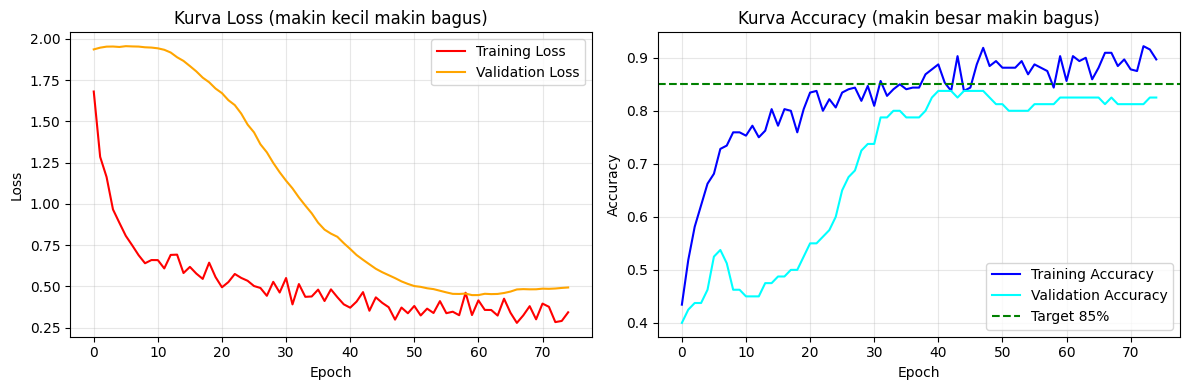

Grafik disimpan → saved_model/training_curve.png


In [31]:
# ── Grafik Kurva Training ─────────────────────────────────────────────────
# Grafik ini menunjukkan bagaimana loss dan accuracy berubah setiap epoch
# Berguna untuk mendeteksi masalah seperti:
#   - Overfitting: training acc naik tapi val acc turun
#   - Underfitting: keduanya rendah dan tidak naik

# Buat canvas dengan 2 grafik berdampingan
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Grafik kiri: Loss
ax1.plot(history.history['loss'],     label='Training Loss',   color='red')
ax1.plot(history.history['val_loss'], label='Validation Loss', color='orange')
ax1.set_title('Kurva Loss (makin kecil makin bagus)')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)  # tambahkan grid samar untuk memudahkan membaca

# Grafik kanan: Accuracy
ax2.plot(history.history['accuracy'],     label='Training Accuracy',   color='blue')
ax2.plot(history.history['val_accuracy'], label='Validation Accuracy', color='cyan')
# Garis putus-putus hijau = target akurasi 85%
ax2.axhline(y=0.85, color='green', linestyle='--', label='Target 85%')
ax2.set_title('Kurva Accuracy (makin besar makin bagus)')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

# tight_layout() = atur jarak antar grafik supaya tidak tumpang tindih
plt.tight_layout()

# Simpan grafik ke file PNG
plt.savefig('saved_model/training_curve.png', dpi=100, bbox_inches='tight')
plt.show()
print('Grafik disimpan → saved_model/training_curve.png')

## Step 11 — Simpan Model, Scaler & Daftar Fitur

In [32]:
# ── Simpan model ─────────────────────────────────────────────────────────
# model.save() menyimpan SELURUH model:
#   - Arsitektur (susunan layer)
#   - Bobot yang sudah dipelajari
#   - Konfigurasi optimizer dan loss
# Format .keras adalah format terbaru TensorFlow (lebih baik dari .h5)
model.save(MODEL_PATH)
print(f'Model disimpan   → {MODEL_PATH}')

# ── Simpan scaler ─────────────────────────────────────────────────────────
# WAJIB! Scaler HARUS disimpan dan dipakai ulang saat inference
# Kenapa? Karena scaler menyimpan nilai min dan max dari data training
# Kalau pakai scaler baru saat inference, normalisasinya akan berbeda
# dan prediksi model akan salah meskipun modelnya benar
joblib.dump(scaler, SCALER_PATH)
print(f'Scaler disimpan  → {SCALER_PATH}')

# ── Simpan nama fitur ─────────────────────────────────────────────────────
# Nama fitur harus disimpan supaya saat inference kita tahu:
#   - Fitur apa saja yang dibutuhkan
#   - Urutannya harus sama persis dengan saat training
with open(FEATURES_PATH, 'w') as f:
    for name in feat_names:
        f.write(name + '\n')  # tulis satu nama fitur per baris
print(f'Fitur disimpan   → {FEATURES_PATH}')

print('\nSemua file tersimpan di folder saved_model/')
print('File-file ini yang nanti di-upload ke server backend.')

Model disimpan   → saved_model/placement_model.keras
Scaler disimpan  → saved_model/placement_scaler.pkl
Fitur disimpan   → saved_model/feature_names.txt

Semua file tersimpan di folder saved_model/
File-file ini yang nanti di-upload ke server backend.


## Step 12 — Test Inference
> Simulasi: bagaimana model dipanggil dari aplikasi web saat siswa selesai pre-test

In [33]:
# ── Load model dan scaler dari file ──────────────────────────────────────
# Di aplikasi nyata, bagian ini dijalankan SEKALI saat server FastAPI start
# (tidak perlu load ulang setiap ada request masuk)

# keras.models.load_model() memuat model dari file .keras
# custom_objects: daftar kelas custom yang dipakai model
# (TensorFlow perlu tahu definisinya untuk merekonstruksi model)
model_loaded = keras.models.load_model(
    MODEL_PATH,
    custom_objects={
        'TopicAttentionLayer'      : TopicAttentionLayer,
        'WeightedCrossEntropyLoss' : WeightedCrossEntropyLoss,
    }
)

# joblib.load() memuat scaler dari file .pkl
scaler_loaded = joblib.load(SCALER_PATH)

# Baca nama fitur dari file teks — ubah jadi list
feat_names_loaded = open(FEATURES_PATH).read().splitlines()

print('Model, scaler, dan fitur berhasil di-load ✓')
print(f'Jumlah fitur yang dibutuhkan: {len(feat_names_loaded)}')

Model, scaler, dan fitur berhasil di-load ✓
Jumlah fitur yang dibutuhkan: 13


c:\Users\Acer\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\layer.py:427: UserWarning: `build()` was called on layer 'topic_attention', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


In [34]:
def predict_placement(hasil_pretest: dict, model, scaler, feat_names) -> dict:
    # Fungsi ini yang nantinya dibungkus endpoint FastAPI /predict/placement
    # Dipanggil setiap kali siswa selesai mengerjakan pre-test
    #
    # Input  : dict berisi hasil pre-test siswa (dari tim Full-Stack)
    # Output : dict berisi rekomendasi level dan modul awal (dikirim ke Full-Stack)

    # LANGKAH 1: Ambil nilai fitur sesuai urutan yang dipakai saat training
    # .get(nama, 0.0) = ambil nilai fitur; kalau tidak ada, isi 0.0
    # Urutan HARUS sama persis dengan feat_names saat training
    fitur_values = [hasil_pretest.get(nama, 0.0) for nama in feat_names]

    # LANGKAH 2: Ubah list menjadi numpy array dengan bentuk (1, n_fitur)
    # reshape(1, -1) = ubah jadi 1 baris (karena hanya 1 siswa)
    # Model butuh input berbentuk 2D: (jumlah_siswa, jumlah_fitur)
    X = np.array(fitur_values, dtype=np.float32).reshape(1, -1)

    # LANGKAH 3: Normalisasi dengan scaler yang SAMA saat training
    # transform() = terapkan normalisasi menggunakan min/max yang sudah dipelajari
    # (bukan fit_transform() karena kita tidak 'belajar' dari data baru)
    X_scaled = scaler.transform(X)

    # LANGKAH 4: Prediksi — hasilkan probabilitas per kelas
    # verbose=0 = tidak tampilkan progress bar
    # [0] = ambil baris pertama (karena hanya 1 siswa)
    proba = model.predict(X_scaled, verbose=0)[0]
    # proba sekarang berisi 3 angka, contoh: [0.1, 0.2, 0.7]

    # LANGKAH 5: Tentukan kelas dengan probabilitas tertinggi
    # np.argmax() = cari index nilai terbesar
    level_index = int(np.argmax(proba))

    # Ambil nilai probabilitas tertinggi sebagai confidence score
    confidence = float(proba[level_index])

    # LANGKAH 6: Kembalikan hasil dalam format dict (akan diubah jadi JSON)
    return {
        'level'           : LABEL_MAP[level_index],     # nama level: 'pemula'/'menengah'/'mahir'
        'level_index'     : level_index,                # angka: 0, 1, atau 2
        'mulai_dari_modul': MODUL_MAP[level_index],     # nomor modul awal di quest map
        'confidence'      : round(confidence, 4),       # seberapa yakin model (0.0-1.0)
        'probabilitas'    : {                           # probabilitas lengkap per kelas
            LABEL_MAP[i]: round(float(proba[i]), 4)
            for i in range(len(proba))
        }
    }


print('Fungsi predict_placement() siap ✓')

Fungsi predict_placement() siap ✓


In [35]:
# ── Simulasi: siswa baru selesai pre-test ─────────────────────────────────
# Ini menyimulasikan data yang akan dikirim oleh tim Full-Stack
# setiap kali seorang siswa menyelesaikan pre-test

# Buat input dengan semua fitur diisi 0 dulu
contoh_input = {nama: 0.0 for nama in feat_names_loaded}

# Isi fitur global
contoh_input['avg_waktu']   = 35.0   # rata-rata 35 detik per soal → agak lambat
contoh_input['jumlah_soal'] = 20     # mengerjakan 20 soal pre-test
contoh_input['topik_unik']  = 6      # mengerjakan soal dari 6 topik berbeda

# Isi akurasi per topik — rendah semua → kemungkinan pemula
np.random.seed(10)
for nama in feat_names_loaded:
    if nama.startswith('akurasi_topik'):  # hanya kolom akurasi topik
        contoh_input[nama] = round(np.random.uniform(0.1, 0.4), 2)  # akurasi 10-40%

# Jalankan prediksi
hasil = predict_placement(contoh_input, model_loaded, scaler_loaded, feat_names_loaded)

# Tampilkan hasil
print('=' * 50)
print('HASIL PREDIKSI PLACEMENT')
print('=' * 50)
print(f'Level              : {hasil["level"]}')
print(f'Mulai dari modul   : {hasil["mulai_dari_modul"]}')
print(f'Confidence         : {hasil["confidence"]*100:.1f}%')
print(f'\nProbabilitas per level:')
for kelas, prob in hasil['probabilitas'].items():
    # Buat bar chart sederhana dari karakter █
    bar = '█' * int(prob * 25)
    print(f'  {kelas:>8}: {prob:.2f} {bar}')

print('\n' + '=' * 50)
print('Format JSON yang dikirim ke Full-Stack:')
print('=' * 50)

# Tampilkan sebagai JSON — format ini yang akan dikembalikan endpoint FastAPI
import json
print(json.dumps(hasil, indent=2, ensure_ascii=False))

c:\Users\Acer\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


HASIL PREDIKSI PLACEMENT
Level              : pemula
Mulai dari modul   : 1
Confidence         : 99.7%

Probabilitas per level:
    pemula: 1.00 ████████████████████████
  menengah: 0.00 
     mahir: 0.00 

Format JSON yang dikirim ke Full-Stack:
{
  "level": "pemula",
  "level_index": 0,
  "mulai_dari_modul": 1,
  "confidence": 0.9972,
  "probabilitas": {
    "pemula": 0.9972,
    "menengah": 0.0017,
    "mahir": 0.0011
  }
}


## ✅ Pipeline Selesai!

### File yang dihasilkan di folder `saved_model/`:
| File | Kegunaan |
|------|----------|
| `placement_model.keras` | Model yang sudah dilatih — di-load oleh FastAPI |
| `placement_scaler.pkl` | Scaler normalisasi — wajib di-load bersama model |
| `feature_names.txt` | Daftar fitur — pastikan urutan sama saat inference |
| `training_log.csv` | Log metrik tiap epoch — untuk dokumentasi |
| `training_curve.png` | Grafik loss & accuracy — untuk laporan |

### Langkah berikutnya:
1. **Ganti data dummy** dengan dataset Junyi Academy dari Kaggle
2. **Jalankan ulang** notebook dari Step 5
3. **Cek akurasi** — target ≥ 85%
4. **Upload** file `saved_model/` ke server backend
5. **Bungkus** fungsi `predict_placement()` ke dalam endpoint FastAPI `/predict/placement`
